<a href="https://colab.research.google.com/github/dilekmirac/dip/blob/main/hafta3_g%C3%B6rev4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

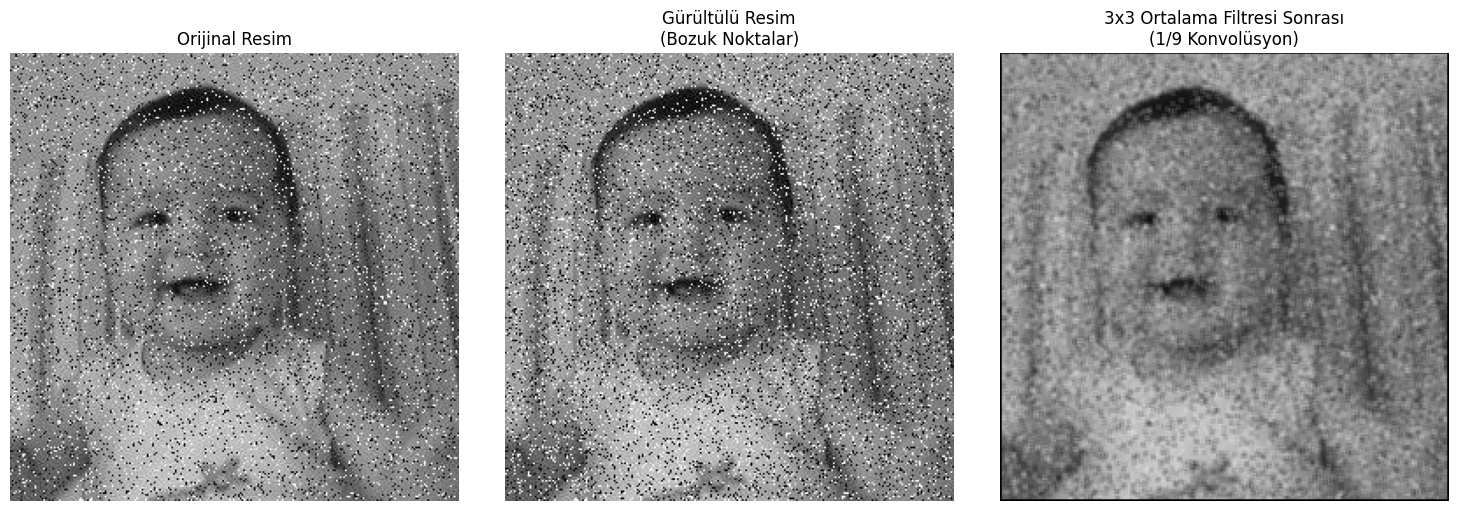

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('insan.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.ones((400, 400), dtype=np.uint8) * 128

yukseklik, genislik = img.shape

img_gurultulu = img.copy()
gurultu_miktari = 3000
for _ in range(gurultu_miktari):
    rastgele_y = np.random.randint(1, yukseklik - 1)
    rastgele_x = np.random.randint(1, genislik - 1)
    img_gurultulu[rastgele_y, rastgele_x] = np.random.choice([0, 255])

img_filtrelenmis = np.zeros((yukseklik, genislik), dtype=np.uint8)

for i in range(1, yukseklik - 1):
    for j in range(1, genislik - 1):

        toplam = (
            int(img_gurultulu[i-1, j-1]) + int(img_gurultulu[i-1, j]) + int(img_gurultulu[i-1, j+1]) +
            int(img_gurultulu[i, j-1])   + int(img_gurultulu[i, j])   + int(img_gurultulu[i, j+1]) +
            int(img_gurultulu[i+1, j-1]) + int(img_gurultulu[i+1, j]) + int(img_gurultulu[i+1, j+1])
        )

        yeni_piksel = toplam / 9.0

        img_filtrelenmis[i, j] = int(yeni_piksel)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Orijinal Resim")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gurultulu, cmap='gray', vmin=0, vmax=255)
plt.title("Gürültülü Resim\n(Bozuk Noktalar)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_filtrelenmis, cmap='gray', vmin=0, vmax=255)
plt.title("3x3 Ortalama Filtresi Sonrası\n(1/9 Konvolüsyon)")
plt.axis('off')

plt.tight_layout()
plt.show()